In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [88]:
df = pd.read_csv('/content/train.csv', encoding='latin-1')

In [89]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [90]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

In [91]:
print('Data Loaded : ',df.shape)

Data Loaded :  (9800, 18)


In [92]:
ref_date = df['Order Date'].max()
print(f"Reference data : {ref_date} ")

Reference data : 2018-12-30 00:00:00 


In [93]:
rfm = df.groupby('Customer ID').agg(
    Recency = ('Order Date', lambda x: (ref_date - x.max()).days),
    Frequency = ('Order ID', 'nunique'),
    Monetary = ('Sales', 'sum')
).reset_index()

print(f"RFM Shape: {rfm.shape}")
print(f"\nRFM Stats:\n{rfm.describe()}")

RFM Shape: (793, 4)

RFM Stats:
           Recency   Frequency      Monetary
count   793.000000  793.000000    793.000000
mean    148.286255    6.206810   2851.874884
std     187.081466    2.525647   2620.668723
min       0.000000    1.000000      4.833000
25%      30.000000    4.000000   1081.466000
50%      75.000000    6.000000   2215.002000
75%     184.000000    8.000000   3670.258000
max    1165.000000   17.000000  25043.050000


###RFM Visulization

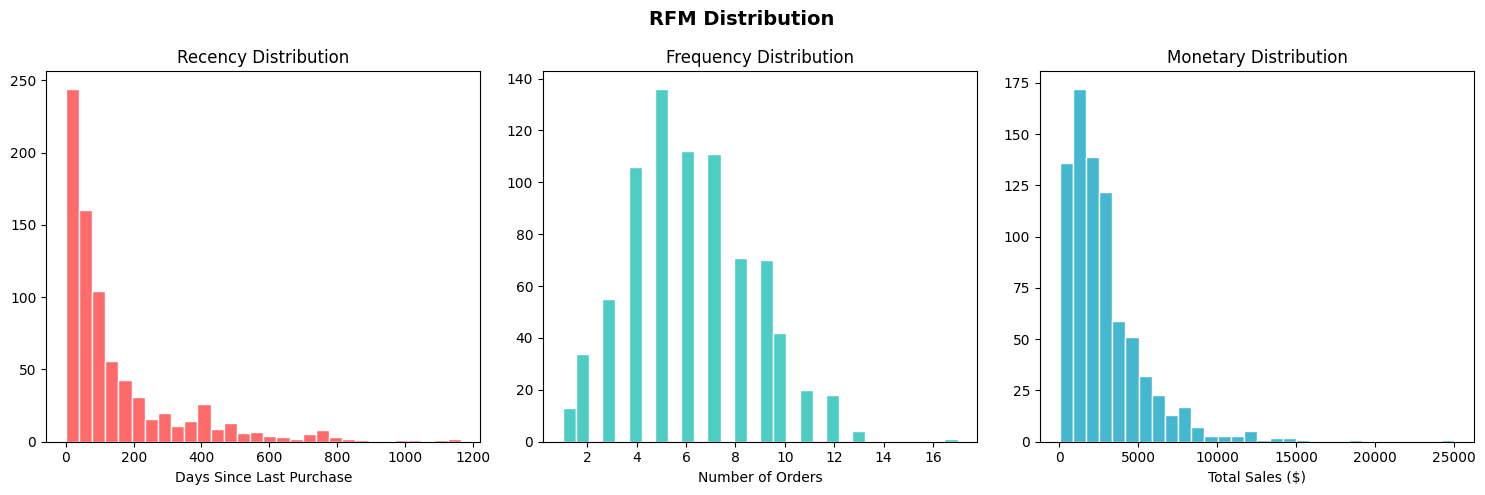

In [94]:
import os

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RFM Distribution ', fontsize=14, fontweight='bold')

axes[0].hist(
    rfm['Recency'],
    bins=30,
    color='#FF6B6B',
    edgecolor='white'
)
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')

axes[1].hist(
    rfm['Frequency'],
    bins=30,
    color='#4ECDC4',
    edgecolor='white'
)
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Orders')

axes[2].hist(
    rfm['Monetary'],
    bins=30,
    color='#45B7D1',
    edgecolor='white'
)
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Sales ($)')

plt.tight_layout()

os.makedirs('notebooks', exist_ok=True)

plt.savefig('notebooks/15_rfm_distribution.png', dpi=150)
plt.show()

In [95]:
rfm['R_log'] = np.log1p(rfm['Recency'])
rfm['F_log'] = np.log1p(rfm['Frequency'])
rfm['M_log'] = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['R_log', 'F_log', 'M_log']])
print(f"Scaled RFM Shape : {rfm_scaled.shape}")
print("Before Scaling:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

Scaled RFM Shape : (793, 3)
Before Scaling:
           Recency   Frequency      Monetary
count   793.000000  793.000000    793.000000
mean    148.286255    6.206810   2851.874884
std     187.081466    2.525647   2620.668723
min       0.000000    1.000000      4.833000
25%      30.000000    4.000000   1081.466000
50%      75.000000    6.000000   2215.002000
75%     184.000000    8.000000   3670.258000
max    1165.000000   17.000000  25043.050000


###Find Optimal K

K=2: Inertia=1486, Silhouette=0.346
K=3: Inertia=1189, Silhouette=0.256
K=4: Inertia=988, Silhouette=0.257
K=5: Inertia=861, Silhouette=0.249
K=6: Inertia=763, Silhouette=0.249
K=7: Inertia=690, Silhouette=0.243
K=8: Inertia=628, Silhouette=0.241


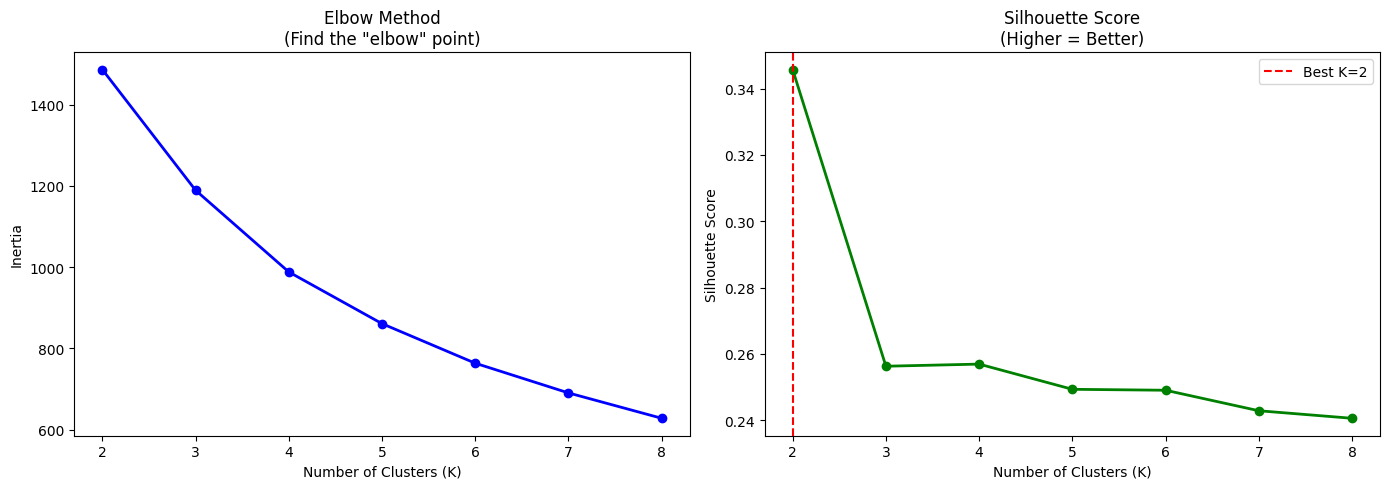


✅ Optimal K = 2


In [96]:
from sklearn.metrics import silhouette_score as _silhouette_score_func

inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)

    inertias.append(kmeans.inertia_)
    sil_score = _silhouette_score_func(
        rfm_scaled,
        kmeans.labels_
    )
    silhouette_scores.append(sil_score)
    print(
        f"K={k}: Inertia={kmeans.inertia_:.0f}, "
        f"Silhouette={sil_score:.3f}"
    )


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(
    k_range, inertias,
    marker='o', color='blue',
    linewidth=2
)
axes[0].set_title(
    'Elbow Method\n(Find the "elbow" point)',
    fontsize=12
)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(
    k_range, silhouette_scores,
    marker='o', color='green',
    linewidth=2
)
best_k = k_range[
    silhouette_scores.index(max(silhouette_scores))
]
axes[1].axvline(
    x=best_k,
    color='red',
    linestyle='--',
    label=f'Best K={best_k}'
)
axes[1].set_title(
    'Silhouette Score\n(Higher = Better)',
    fontsize=12
)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    'notebooks/16_optimal_k.png',
    dpi=150
)
plt.show()
print(f"\n✅ Optimal K = {best_k}")

###KMeans Clustering

In [97]:
print(f"KMeans Clustering (k={4})")
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_profile = rfm.groupby('Cluster').agg(
    Count=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(2)


cluster_names = {
    3: 'Champions',
    1: 'Loyal Customers',
    0: 'At Risk',
    2: 'Lost Customers'
}


cluster_profile['Segment'] = cluster_profile.index.map(cluster_names)
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

print("--- Exact Cluster Summary ---")
print(cluster_profile[['Segment', 'Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Revenue']])

print("\n--- Final Customer Distribution ---")
print(rfm['Segment'].value_counts())


KMeans Clustering (k=4)
--- Exact Cluster Summary ---
                 Segment  Count  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Cluster                                                                     
0                At Risk    277       220.33           4.93       1984.82   
1        Loyal Customers    183        17.60           6.62       2655.97   
2         Lost Customers     87       348.59           2.56        446.63   
3              Champions    246        93.54           8.62       4824.56   

         Total_Revenue  
Cluster                 
0            549796.40  
1            486042.53  
2             38856.40  
3           1186841.45  

--- Final Customer Distribution ---
Segment
At Risk            277
Champions          246
Loyal Customers    183
Lost Customers      87
Name: count, dtype: int64


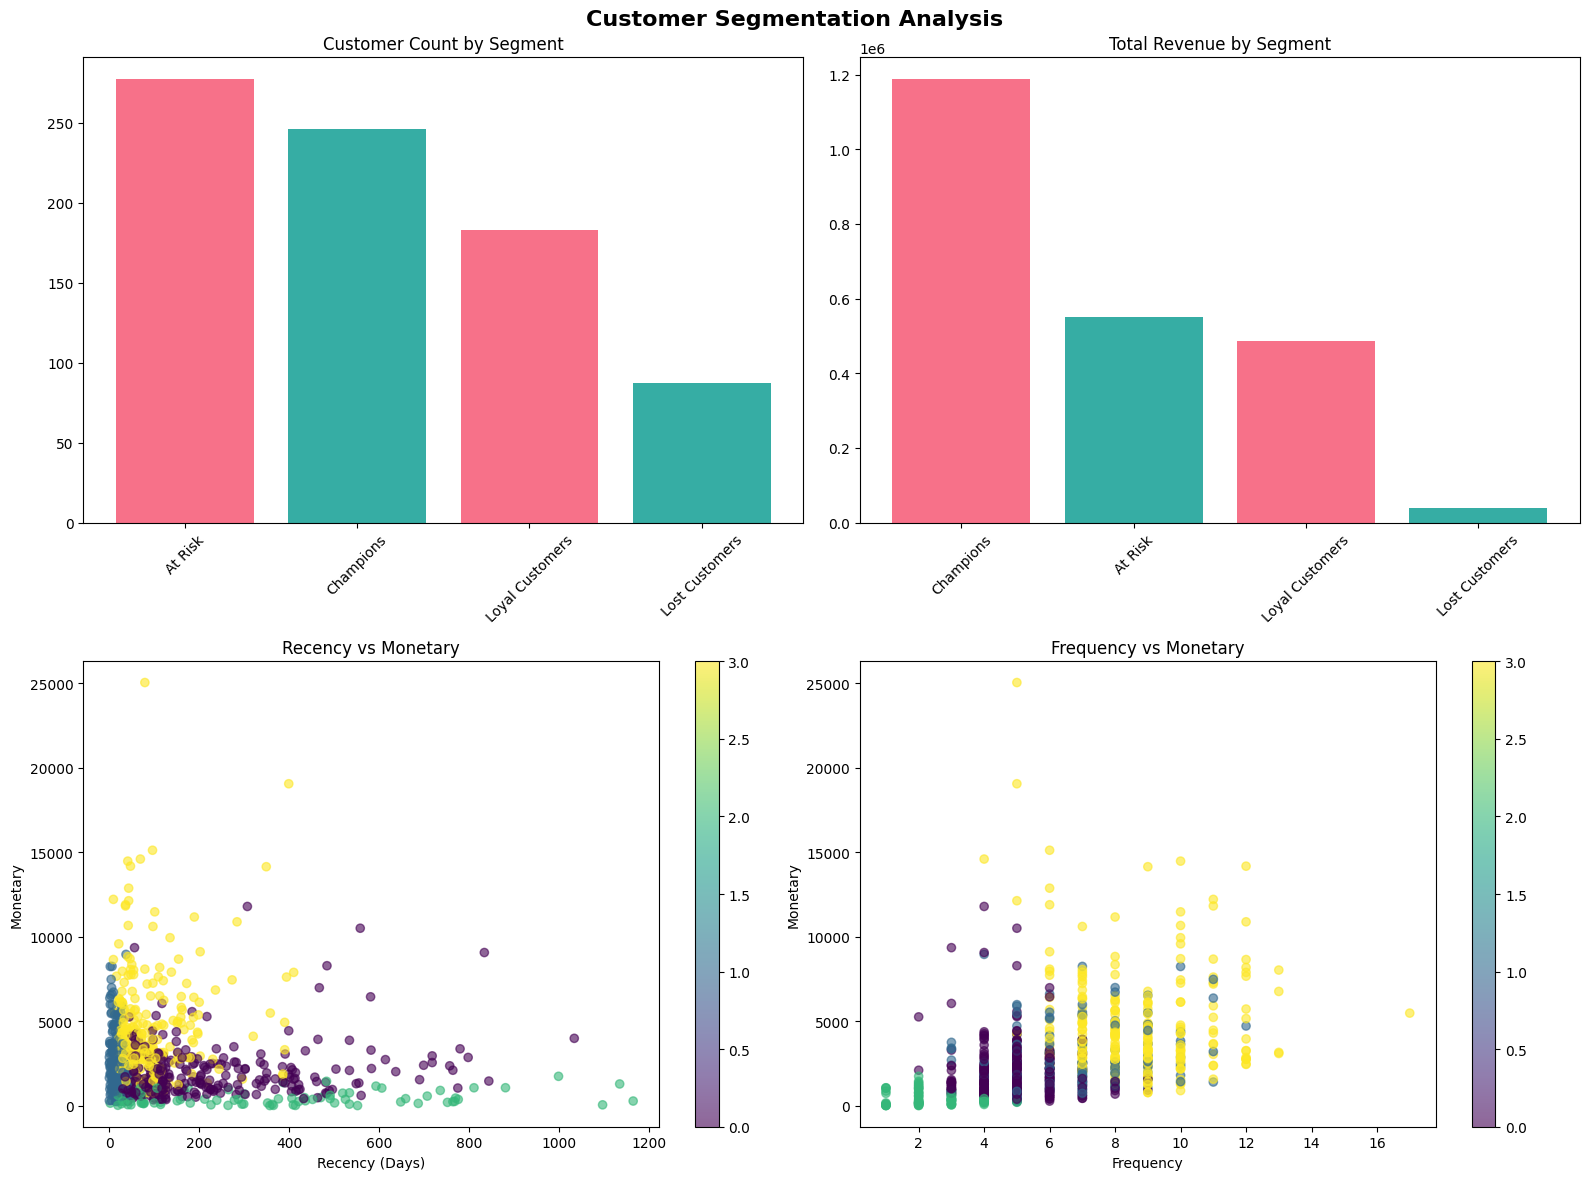

In [98]:
fig, axes = plt.subplots(2,2, figsize=(16,12))
fig.suptitle('Customer Segmentation Analysis', fontsize=16, fontweight='bold')

colors = sns.color_palette('husl', best_k)

seg_count = rfm['Segment'].value_counts()
axes[0,0].bar(
    seg_count.index,
    seg_count.values,
    color=colors[:len(seg_count)]
)
axes[0,0].set_title('Customer Count by Segment')
axes[0,0].set_xticklabels(seg_count.index, rotation=45)

seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
axes[0,1].bar(
    seg_revenue.index,
    seg_revenue.values,
    color=colors[:len(seg_revenue)]
)
axes[0,1].set_title('Total Revenue by Segment')
axes[0,1].set_xticklabels(seg_revenue.index, rotation=45)

scatter = axes[1,0].scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)
axes[1,0].set_title('Recency vs Monetary')
axes[1,0].set_xlabel('Recency (Days)')
axes[1,0].set_ylabel('Monetary')
plt.colorbar(scatter, ax=axes[1,0])

scatter2 = axes[1,1].scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)
axes[1,1].set_title('Frequency vs Monetary')
axes[1,1].set_xlabel('Frequency')
axes[1,1].set_ylabel('Monetary')
plt.colorbar(scatter2, ax=axes[1,1])

plt.tight_layout()
plt.savefig('notebooks/17_segmentation.png',dpi=150)
plt.show()

In [99]:
import os
os.makedirs('data', exist_ok=True)
rfm.to_csv('data/customer_segments.csv', index=False)
cluster_profile.to_csv('data/cluster_profiles.csv')

In [100]:
import os
import pickle
os.makedirs('models', exist_ok=True)
with open('models/kmeans_model.pkl', 'wb') as f:
  pickle.dump(kmeans, f)

with open('models/scaler.pkl', 'wb') as f:
  pickle.dump(scaler, f)